In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os, sys

sys.path.append(os.getenv('PROJECT_DIR'))
from utils.functions import *
from utils.assets import UNIV
from utils.assets import SHORT_UNIV
from utils.strats_technical import TechnicalStrat
from utils.strats_returns import ReturnPredictionStrat
from utils.strats_regimes import RegimePredictionStrat

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None)

In [2]:
fee = 2e-3

hist_start_date_str = '2021-01-01'
hist_end_date_str = '2023-12-31'
fut_start_date_str = '2024-01-01'
fut_end_date_str = '2024-12-31'

validation_stats = pd.DataFrame(columns=['total_returns', 'sharpe_ratio', 'bnh_sharpe_ratio', 'volatility', 'α_coeff', 'α_t_stat', 'IR'])
validation_rets = pd.DataFrame(columns=['tech_strat', 'ml_returns_strat', 'ml_regimes_strat', 'comb_eq_dol_strat'])

# Run technical strat

Pulling historical data for backtests...
Running strat backtests...
Combining historical strats...
Pulling data for OOS trading...
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     51.51
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           4.03e-12
Time:                        20:31:11   Log-Likelihood:                 820.15
No. Observations:                 366   AIC:                            -1636.
Df Residuals:                     364   BIC:                            -1628.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]


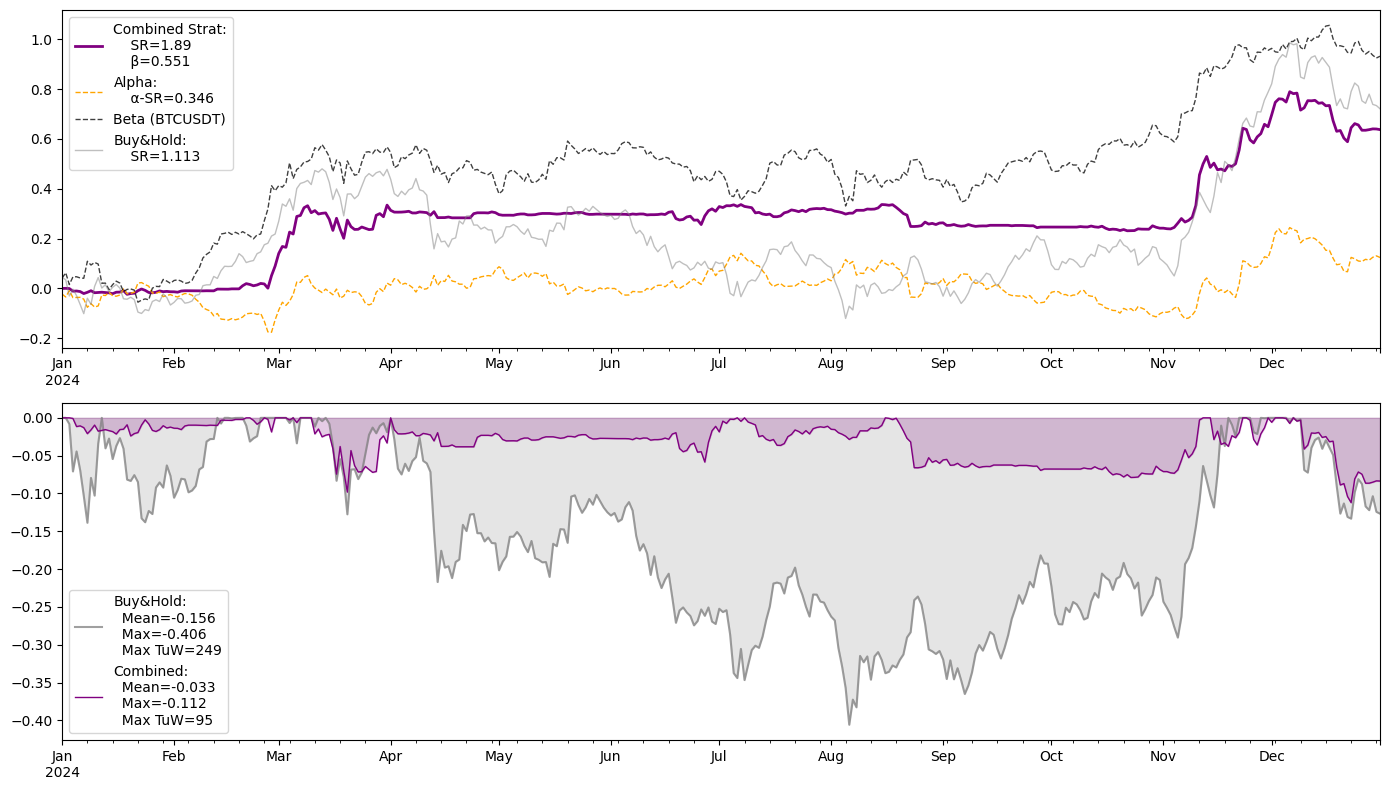

<Figure size 640x480 with 0 Axes>

In [3]:
tech_strat = TechnicalStrat(
    universe=UNIV,
    hist_start_date_str=hist_start_date_str,
    hist_end_date_str=hist_end_date_str,
    fut_start_date_str=fut_start_date_str,
    fut_end_date_str=fut_end_date_str,
    fee=fee
)

tech_strat_rets, tech_strat_wgts, tech_strat_sr, tech_strat_vol, tech_strat_oos_rets, tech_strat_oos_wgts, oos_bnh_rets, oos_beta_rets = tech_strat.run_historical(print_corrs=False)

In [4]:
tech_strat_sr = sharpe_ratio(tech_strat_oos_rets.sum(1), n_periods=365)
tech_strat_vol = tech_strat_oos_rets.sum(1).std()

tech_strat_alpha_coeff = 0.0016
tech_strat_t_stat = 1.171

bnh_sr = sharpe_ratio(oos_bnh_rets, n_periods=365)

strat_name = 'tech_strat'
validation_rets[strat_name] = tech_strat_oos_rets.sum(1)
validation_stats = pd.DataFrame({
    'total_returns': tech_strat_oos_rets.sum(1).sum(),
    'sharpe_ratio': tech_strat_sr,
    'bnh_sharpe_ratio': bnh_sr,
    'volatility': tech_strat_vol,
    'α_coeff': tech_strat_alpha_coeff,
    'α_t_stat': tech_strat_t_stat,
    'IR': information_ratio(tech_strat_oos_rets.sum(1), oos_bnh_rets, 365)
}, index=[strat_name])
    
validation_stats

,total_returns,sharpe_ratio,bnh_sharpe_ratio,volatility,α_coeff,α_t_stat,IR
tech_strat,0.63756,1.890177,1.112811,0.017607,0.0016,1.171,-0.138999


# Run return prediction strat

[*********************100%***********************]  1 of 1 completed


Hist: 2021-01-01 - 2023-12-31 | Fut: 2024-01-01 - 2025-12-30
(5046, 25)
 |##################################################| 100.0% 
************************
*** BACKTEST RESULTS ***
************************
Best (no fees) Sharpe Ratio: 0.7517438875603029
Best fn score: 0.3249558127101768
Best proba threshold: 0.95
Best model params: {'n_estimators': 1000, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'colsample_bylevel': 1.0}
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     160.6
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           9.66e-31
Time:                        20:31:24   Log-Likelihood:                 1310.4
No. Observations:                 366   AIC:                

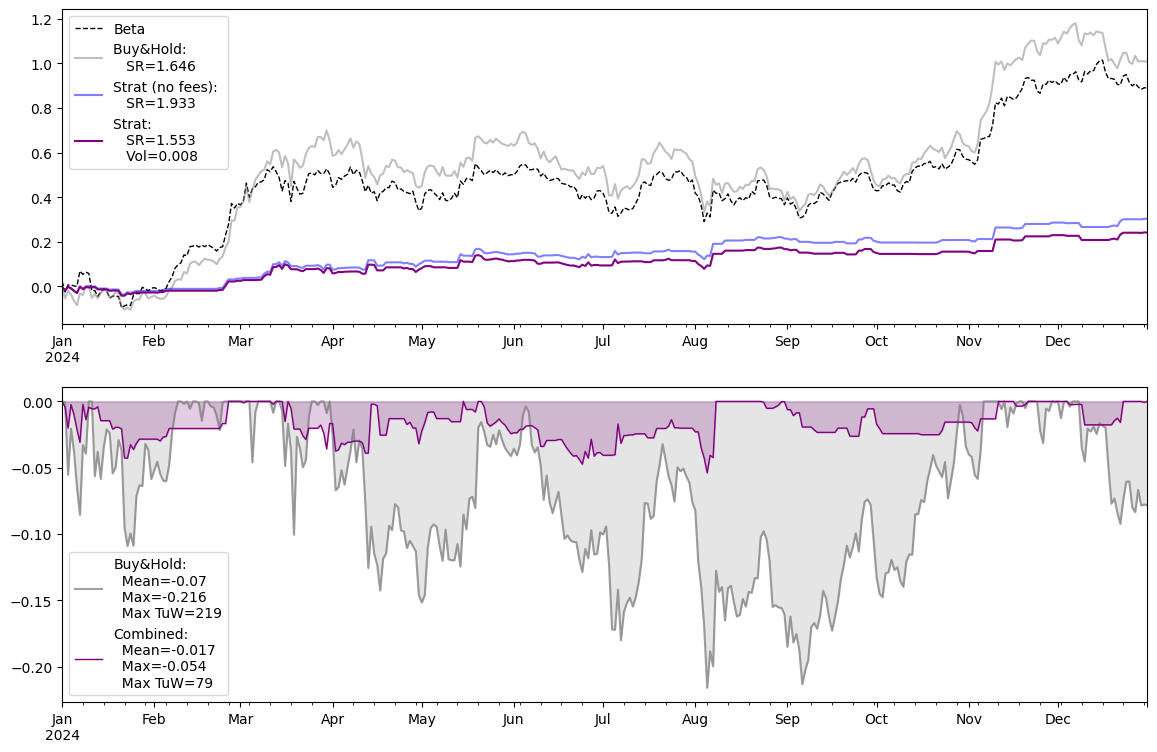

<Figure size 640x480 with 0 Axes>

In [5]:
ret_pred_strat = ReturnPredictionStrat(
    universe=SHORT_UNIV,
    hist_start_date_str=hist_start_date_str,
    hist_end_date_str=hist_end_date_str,
    fut_start_date_str=fut_start_date_str,
    fut_end_date_str=fut_end_date_str,
    fee=fee
)

fee_multiplier = 2.5
custom_thresholds_list = [0.95]

# previously ran grid search over more params, but once
# best params were determined in older runs, only chose
# best params here to speed up testing
grid_search_params_dict = {
    'n_estimators': [1000],
    'subsample': [0.8],
    'colsample_bytree': [1.0], 
    'colsample_bylevel': [1.0],
    'reg_alpha': [0.0],
    'reg_lambda': [0.0]
}
ret_pred_outputs = ret_pred_strat.run_historical(
    cv_splits=3,
    f_score_n=3,
    rolling_window=730,
    fee_multiplier=fee_multiplier,
    custom_thresholds_list=custom_thresholds_list,
    grid_search_params_dict=grid_search_params_dict
)

ret_pred_strat_sr, ret_pred_strat_vol, ret_pred_oos_strat_rets, ret_pred_oos_strat_wgts, ret_pred_oos_fee_mask = ret_pred_outputs

In [6]:
ret_pred_strat_sr = sharpe_ratio(ret_pred_oos_strat_rets.sum(1), n_periods=365)
ret_pred_strat_vol = ret_pred_oos_strat_rets.sum(1).std()

ret_pred_strat_alpha_coeff = 0.0003
ret_pred_strat_t_stat = 0.737

strat_name = 'ml_returns_strat'
validation_rets[strat_name] = ret_pred_oos_strat_rets.sum(1)
    
validation_stats = pd.concat([
    validation_stats, 
    pd.DataFrame(
        {
            'total_returns': ret_pred_oos_strat_rets.sum(1).sum(),
            'sharpe_ratio': ret_pred_strat_sr,
            'bnh_sharpe_ratio': bnh_sr,
            'volatility': ret_pred_strat_vol,
            'α_coeff': ret_pred_strat_alpha_coeff,
            'α_t_stat': ret_pred_strat_t_stat,
            'IR': information_ratio(ret_pred_oos_strat_rets.sum(1), oos_bnh_rets, 365)
        }, index=[strat_name]
    )
])
validation_stats

,total_returns,sharpe_ratio,bnh_sharpe_ratio,volatility,α_coeff,α_t_stat,IR
tech_strat,0.637560,1.890177,1.112811,0.017607,0.0016,1.171,-0.138999
ml_returns_strat,0.241234,1.553406,1.112811,0.008106,0.0003,0.737,-0.710259


# Run regime classification strat

[*********************100%***********************]  1 of 1 completed


Hist: 2021-01-01 - 2023-12-31 | Fut: 2024-01-01 - 2024-12-31

Ticker: BTCUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |##################################################| 100.0% 
Ticker: BNBUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |##################################################| 100.0% 
Ticker: DOGEUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |##################################################| 100.0% 
Ticker: ETHUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |##################################################| 100.0% 
Ticker: SOLUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |###########################

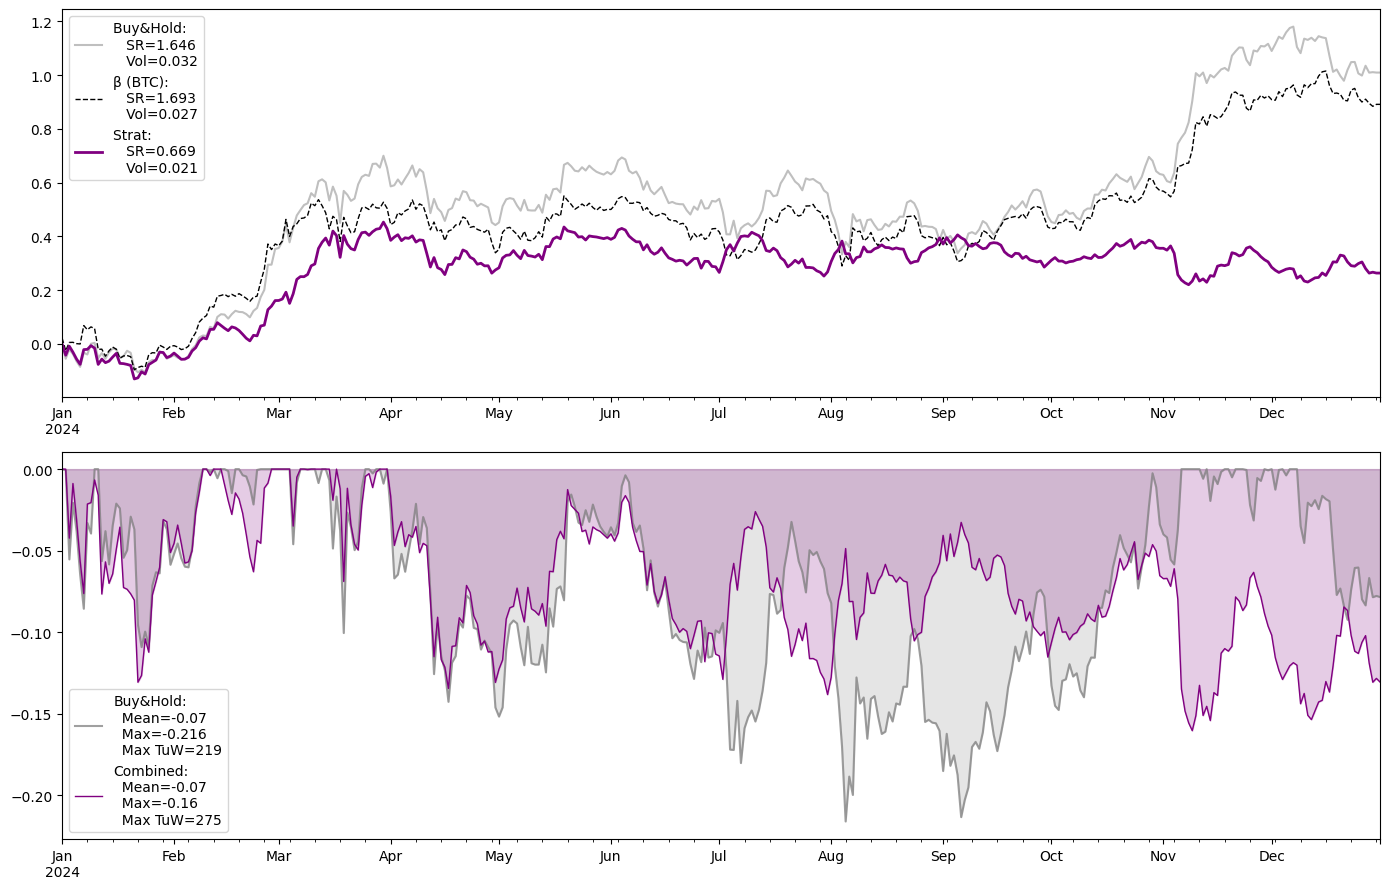

Turnover: 0.114


<Figure size 640x480 with 0 Axes>

In [7]:
regime_strat = RegimePredictionStrat(
    universe=SHORT_UNIV,
    hist_start_date_str=hist_start_date_str,
    hist_end_date_str=hist_end_date_str,
    fut_start_date_str=fut_start_date_str,
    fut_end_date_str=fut_end_date_str,
    fee=fee
)

regime_outputs = regime_strat.run_historical(
    rolling_window=366,
    random_state=12345
)
regime_strat_rets, regime_strat_wgts, regime_strat_sr, regime_strat_vol, regime_oos_strat_rets, regime_oos_strat_wgts = regime_outputs

In [8]:
regime_strat_sr = sharpe_ratio(regime_oos_strat_rets.sum(1), n_periods=365)
regime_strat_vol = regime_oos_strat_rets.sum(1).std()

regime_strat_alpha_coeff = 0.0002
regime_strat_t_stat = 0.187

strat_name = 'ml_regimes_strat'
validation_rets[strat_name] = regime_oos_strat_rets.sum(1)
    
validation_stats = pd.concat([
    validation_stats, 
    pd.DataFrame(
        {
            'total_returns': regime_oos_strat_rets.sum(1).sum(),
            'sharpe_ratio': regime_strat_sr,
            'bnh_sharpe_ratio': bnh_sr,
            'volatility': regime_strat_vol,
            'α_coeff': regime_strat_alpha_coeff,
            'α_t_stat': regime_strat_t_stat,
            'IR': information_ratio(regime_oos_strat_rets.sum(1), oos_bnh_rets, 365)
        }, index=[strat_name]
    )
])
validation_stats

,total_returns,sharpe_ratio,bnh_sharpe_ratio,volatility,α_coeff,α_t_stat,IR
tech_strat,0.637560,1.890177,1.112811,0.017607,0.0016,1.171,-0.138999
ml_returns_strat,0.241234,1.553406,1.112811,0.008106,0.0003,0.737,-0.710259
ml_regimes_strat,0.263314,0.668514,1.112811,0.020560,0.0002,0.187,-0.571849


# Historical performance

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.705
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.101
Time:                        20:35:18   Log-Likelihood:                 1183.1
No. Observations:                 366   AIC:                            -2362.
Df Residuals:                     364   BIC:                            -2354.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.001      1.926      0.0

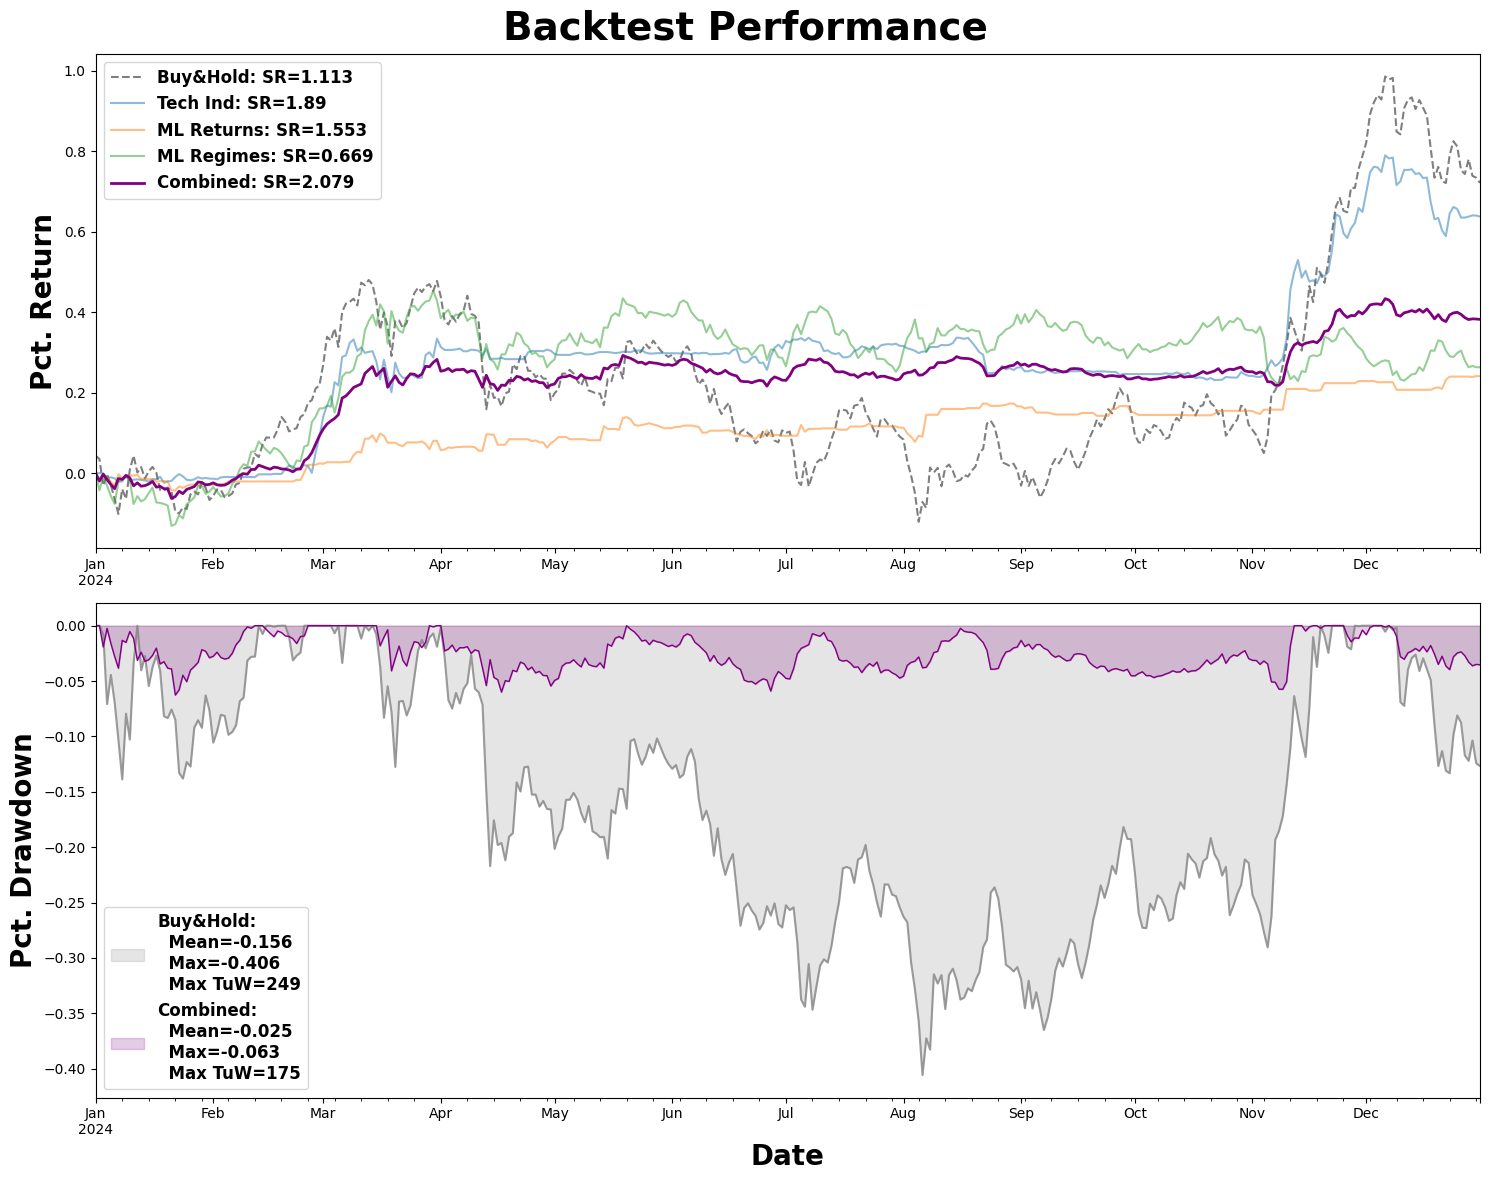

<Figure size 640x480 with 0 Axes>

In [9]:
# use equal dollar weights since no historical performance to use other methods yet
eq_dol_combined_strat_rets = tech_strat_oos_rets.add(ret_pred_oos_strat_rets + regime_oos_strat_rets, fill_value=0) / 3.

# drawdowns
bnh_drawdown = get_drawdown_array(oos_bnh_rets)
strat_drawdown = get_drawdown_array(eq_dol_combined_strat_rets.sum(1))

beta, results = calc_beta(np.array(oos_beta_rets), np.array(eq_dol_combined_strat_rets.sum(1)))
print(results.summary())

fig, axs = plt.subplots(2, 1, figsize=(15, 12))

oos_bnh_rets.cumsum().plot(ax=axs[0], alpha=0.5, color='black', linestyle='--', label=f"Buy&Hold: SR={np.round(sharpe_ratio(oos_bnh_rets, 365), 3)}")
tech_strat_oos_rets.sum(1).cumsum().plot(ax=axs[0], alpha=0.5, label=f"Tech Ind: SR={np.round(sharpe_ratio(tech_strat_oos_rets.sum(1), 365), 3)}")
ret_pred_oos_strat_rets.sum(1).cumsum().plot(ax=axs[0], alpha=0.5, label=f"ML Returns: SR={np.round(sharpe_ratio(ret_pred_oos_strat_rets.sum(1), 365), 3)}")
regime_oos_strat_rets.sum(1).cumsum().plot(ax=axs[0], alpha=0.5, label=f"ML Regimes: SR={np.round(sharpe_ratio(regime_oos_strat_rets.sum(1), 365), 3)}")
eq_dol_combined_strat_rets.sum(1).cumsum().plot(ax=axs[0], color='purple', linewidth=2, label=f"Combined: SR={np.round(sharpe_ratio(eq_dol_combined_strat_rets.sum(1), 365), 3)}")

bnh_drawdown.plot(ax=axs[1], color='gray', alpha=0.75)
axs[1].fill_between(bnh_drawdown.index, bnh_drawdown, y2=0, color='gray', alpha=0.2, label=f"Buy&Hold:\n  Mean={np.round(bnh_drawdown.mean(), 3)}\n  Max={np.round(bnh_drawdown.min(), 3)}\n  Max TuW={max_time_under_water(bnh_drawdown)}")
strat_drawdown.plot(ax=axs[1], color='purple', linewidth=1)
axs[1].fill_between(strat_drawdown.index, strat_drawdown, y2=0, color='purple', alpha=0.2, label=f"Combined:\n  Mean={np.round(strat_drawdown.mean(), 3)}\n  Max={np.round(strat_drawdown.min(), 3)}\n  Max TuW={max_time_under_water(strat_drawdown)}")

axs[0].set_ylabel('Pct. Return', size=20,  weight='bold')
axs[0].legend(loc='upper left', prop={'size': 12, 'weight': 'bold'})
axs[1].set_xlabel('Date', size=20, weight='bold')
axs[1].set_ylabel('Pct. Drawdown', size=20,  weight='bold')
axs[1].legend(loc='lower left', prop={'size': 12, 'weight': 'bold'})
plt.suptitle('Backtest Performance', size=28, weight='bold')
plt.tight_layout()
#plt.savefig('quant_strats_val_perf.png')
plt.show()
plt.clf()

#os.system('open quant_strats_val_perf.png')

In [10]:
comb_eq_dol_strat_sr = sharpe_ratio(eq_dol_combined_strat_rets.sum(1), 365)
comb_eq_dol_strat_vol = eq_dol_combined_strat_rets.sum(1).std()

comb_eq_dol_strat_alpha_coeff = 0.0010
comb_eq_dol_strat_t_stat = 1.926

strat_name = 'comb_eq_dol_strat'
validation_rets[strat_name] = regime_oos_strat_rets.sum(1)

validation_stats = pd.concat([
    validation_stats, 
    pd.DataFrame(
        {
            'total_returns': eq_dol_combined_strat_rets.sum(1).sum(),
            'sharpe_ratio': comb_eq_dol_strat_sr,
            'bnh_sharpe_ratio': bnh_sr,
            'volatility': comb_eq_dol_strat_vol,
            'α_coeff': comb_eq_dol_strat_alpha_coeff,
            'α_t_stat': comb_eq_dol_strat_t_stat,
            'IR': information_ratio(eq_dol_combined_strat_rets.sum(1), oos_bnh_rets, 365)
        }, index=[strat_name]
    )
])
validation_stats

,total_returns,sharpe_ratio,bnh_sharpe_ratio,volatility,α_coeff,α_t_stat,IR
tech_strat,0.637560,1.890177,1.112811,0.017607,0.0016,1.171,-0.138999
ml_returns_strat,0.241234,1.553406,1.112811,0.008106,0.0003,0.737,-0.710259
ml_regimes_strat,0.263314,0.668514,1.112811,0.020560,0.0002,0.187,-0.571849
comb_eq_dol_strat,0.382187,2.078953,1.112811,0.009596,0.0010,1.926,-0.521228


In [11]:
# these validation returns will be used to get weights for OOS trading
validation_rets.head()

,tech_strat,ml_returns_strat,ml_regimes_strat,comb_eq_dol_strat
2024-01-01,0.000000,-0.004454,0.000000,0.000000
2024-01-02,0.000418,-0.015693,-0.042301,-0.042301
2024-01-03,-0.000809,0.017705,0.033486,0.033486
2024-01-04,-0.010708,-0.007638,-0.022126,-0.022126
2024-01-05,0.000895,-0.011097,-0.025470,-0.025470


# OOS Trading

In [12]:
hist_start_date_str = '2021-01-01'
hist_end_date_str = '2024-12-31'
fut_start_date_str = '2025-01-01'
fut_end_date_str = '2026-02-28'

## Run Technical Strat

Pulling historical data for backtests...
Running strat backtests...
Combining historical strats...
Pulling data for OOS trading...
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3414
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.559
Time:                        20:37:39   Log-Likelihood:                 984.44
No. Observations:                 424   AIC:                            -1965.
Df Residuals:                     422   BIC:                            -1957.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]


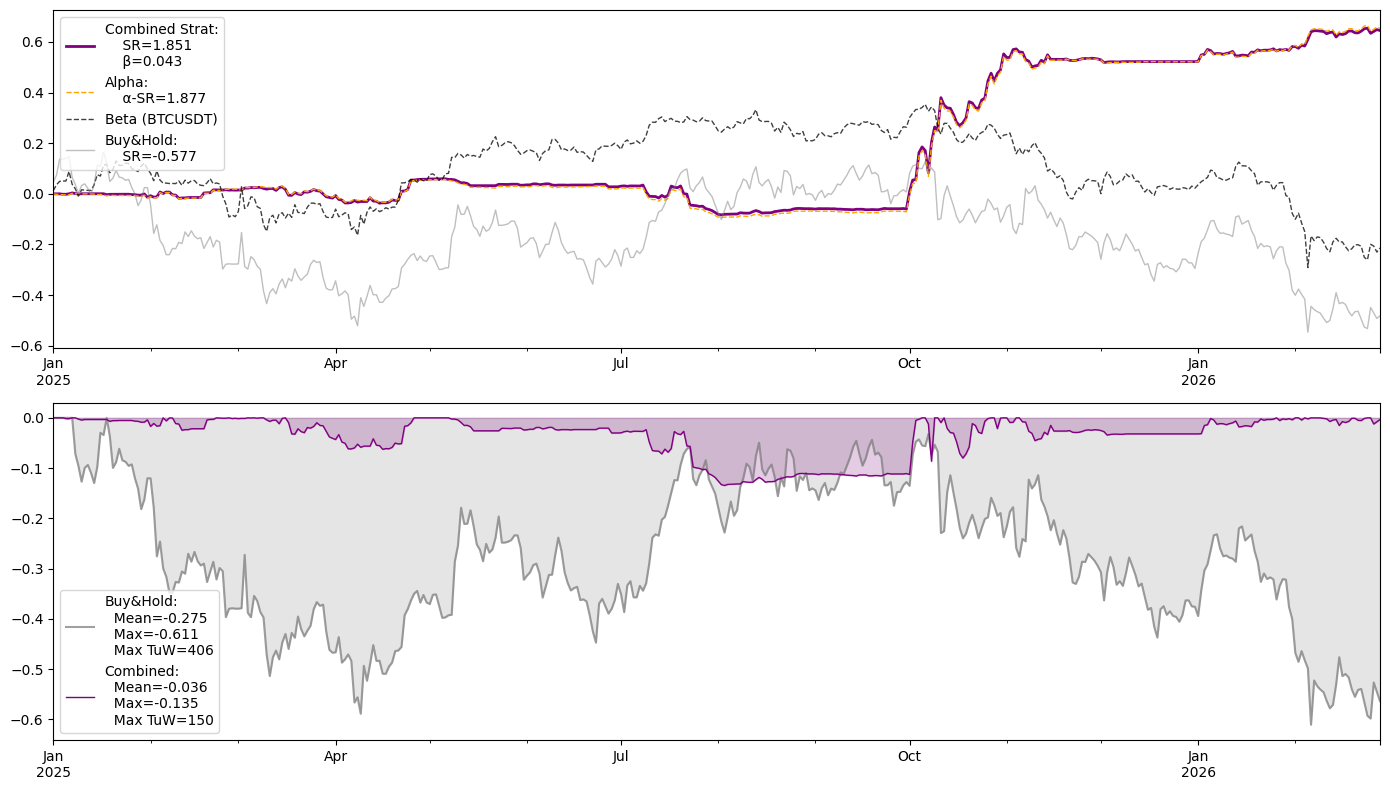

<Figure size 640x480 with 0 Axes>

In [13]:
tech_strat = TechnicalStrat(
    universe=UNIV,
    hist_start_date_str=hist_start_date_str,
    hist_end_date_str=hist_end_date_str,
    fut_start_date_str=fut_start_date_str,
    fut_end_date_str=fut_end_date_str,
    fee=fee
)

tech_strat_rets, tech_strat_wgts, tech_strat_sr, tech_strat_vol, tech_strat_oos_rets, tech_strat_oos_wgts, oos_bnh_rets, oos_beta_rets = tech_strat.run_historical(print_corrs=False)

In [14]:
tech_strat_sr = sharpe_ratio(tech_strat_oos_rets.sum(1), n_periods=365)
tech_strat_vol = tech_strat_oos_rets.sum(1).std()

tech_strat_alpha_coeff = -0.0006
tech_strat_t_stat = -0.491

bnh_sr = sharpe_ratio(oos_bnh_rets, n_periods=365)
    
strat_name = 'oos_tech_strat'
validation_stats = pd.concat([
    validation_stats, 
    pd.DataFrame(
        {
            'total_returns': tech_strat_oos_rets.sum(1).sum(),
            'sharpe_ratio': tech_strat_sr,
            'bnh_sharpe_ratio': bnh_sr,
            'volatility': tech_strat_vol,
            'α_coeff': tech_strat_alpha_coeff,
            'α_t_stat': tech_strat_t_stat,
            'IR': information_ratio(tech_strat_oos_rets.sum(1), oos_bnh_rets, 365)
        }, index=[strat_name]
    )
])
    
validation_stats

,total_returns,sharpe_ratio,bnh_sharpe_ratio,volatility,α_coeff,α_t_stat,IR
tech_strat,0.637560,1.890177,1.112811,0.017607,0.0016,1.171,-0.138999
ml_returns_strat,0.241234,1.553406,1.112811,0.008106,0.0003,0.737,-0.710259
ml_regimes_strat,0.263314,0.668514,1.112811,0.020560,0.0002,0.187,-0.571849
comb_eq_dol_strat,0.382187,2.078953,1.112811,0.009596,0.0010,1.926,-0.521228
oos_tech_strat,0.645185,1.851290,-0.576611,0.015703,-0.0006,-0.491,1.267935


## Run return prediction strat

[*********************100%***********************]  1 of 1 completed


Hist: 2021-01-01 - 2024-12-31 | Fut: 2025-01-01 - 2026-12-31
(6841, 25)
 |##################################################| 100.0% 
************************
*** BACKTEST RESULTS ***
************************
Best (no fees) Sharpe Ratio: 0.7870591726302166
Best fn score: 0.30482508261254454
Best proba threshold: 0.95
Best model params: {'n_estimators': 1000, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'colsample_bylevel': 1.0}
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     202.2
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           9.16e-38
Time:                        20:37:53   Log-Likelihood:                 1512.2
No. Observations:                 424   AIC:               

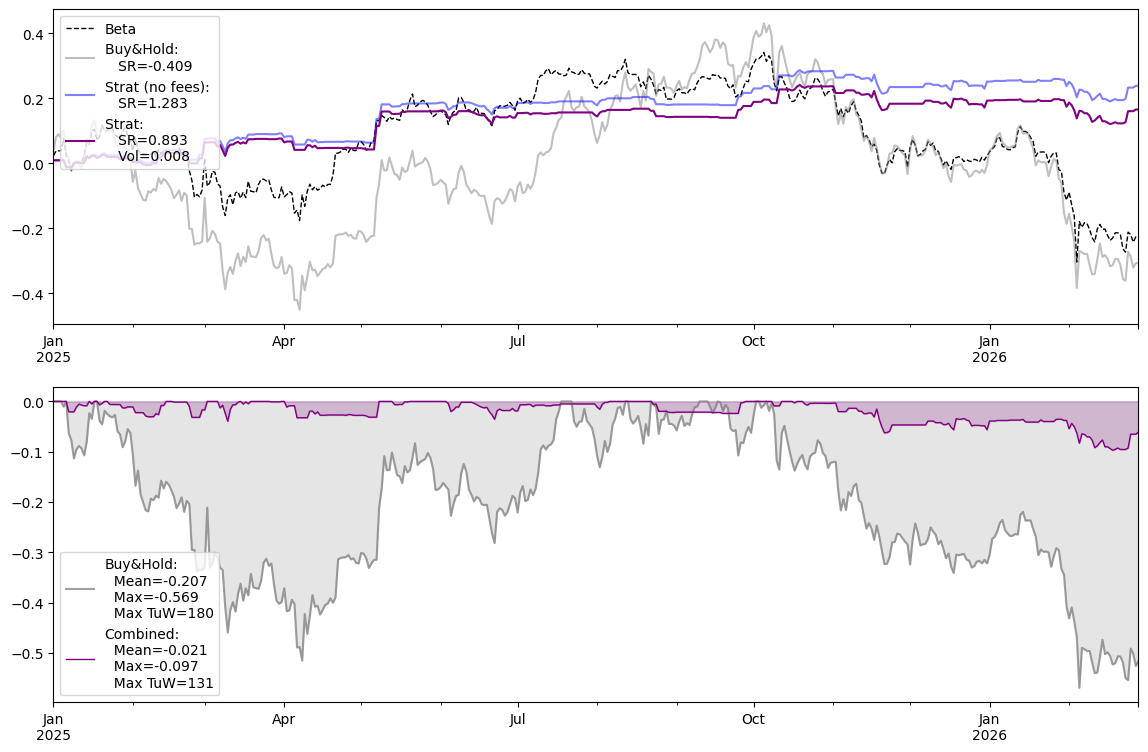

<Figure size 640x480 with 0 Axes>

In [15]:
ret_pred_strat = ReturnPredictionStrat(
    universe=SHORT_UNIV,
    hist_start_date_str=hist_start_date_str,
    hist_end_date_str=hist_end_date_str,
    fut_start_date_str=fut_start_date_str,
    fut_end_date_str=fut_end_date_str,
    fee=fee
)

fee_multiplier = 2.5
custom_thresholds_list = [0.95]

# previously ran grid search over more params, but once
# best params were determined in older runs, only chose
# best params here to speed up testing
grid_search_params_dict = {
    'n_estimators': [1000],
    'subsample': [0.8],
    'colsample_bytree': [1.0], 
    'colsample_bylevel': [1.0],
    'reg_alpha': [0.0],
    'reg_lambda': [0.0]
}
ret_pred_outputs = ret_pred_strat.run_historical(
    cv_splits=3,
    f_score_n=3,
    rolling_window=730,
    fee_multiplier=fee_multiplier,
    custom_thresholds_list=custom_thresholds_list,
    grid_search_params_dict=grid_search_params_dict
)

ret_pred_strat_sr, ret_pred_strat_vol, ret_pred_oos_strat_rets, ret_pred_oos_strat_wgts, ret_pred_oos_fee_mask = ret_pred_outputs

In [16]:
ret_pred_strat_sr = sharpe_ratio(ret_pred_oos_strat_rets.sum(1), n_periods=365)
ret_pred_strat_vol = ret_pred_oos_strat_rets.sum(1).std()

ret_pred_strat_alpha_coeff = 0.0005
ret_pred_strat_t_stat = 1.489

strat_name = 'oos_ml_returns_strat'    
validation_stats = pd.concat([
    validation_stats, 
    pd.DataFrame(
        {
            'total_returns': ret_pred_oos_strat_rets.sum(1).sum(),
            'sharpe_ratio': ret_pred_strat_sr,
            'bnh_sharpe_ratio': bnh_sr,
            'volatility': ret_pred_strat_vol,
            'α_coeff': ret_pred_strat_alpha_coeff,
            'α_t_stat': ret_pred_strat_t_stat,
            'IR': information_ratio(ret_pred_oos_strat_rets.sum(1), oos_bnh_rets, 365)
        }, index=[strat_name]
    )
])
validation_stats

,total_returns,sharpe_ratio,bnh_sharpe_ratio,volatility,α_coeff,α_t_stat,IR
tech_strat,0.637560,1.890177,1.112811,0.017607,0.0016,1.171,-0.138999
ml_returns_strat,0.241234,1.553406,1.112811,0.008106,0.0003,0.737,-0.710259
ml_regimes_strat,0.263314,0.668514,1.112811,0.020560,0.0002,0.187,-0.571849
comb_eq_dol_strat,0.382187,2.078953,1.112811,0.009596,0.0010,1.926,-0.521228
oos_tech_strat,0.645185,1.851290,-0.576611,0.015703,-0.0006,-0.491,1.267935
oos_ml_returns_strat,0.164907,0.892694,-0.576611,0.008324,0.0005,1.489,0.754360


## Run regime classification strat

[*********************100%***********************]  1 of 1 completed


Hist: 2021-01-01 - 2024-12-31 | Fut: 2025-01-01 - 2026-01-01

Ticker: BTCUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |##################################################| 100.0% 
Ticker: BNBUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |##################################################| 100.0% 
Ticker: DOGEUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |##################################################| 100.0% 
Ticker: ETHUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |##################################################| 100.0% 
Ticker: SOLUSDT
Running Grid Search over 1008 parameter combinations.
Kfold cross-validation with 3 folds --> 3024 total iterations
 |###########################

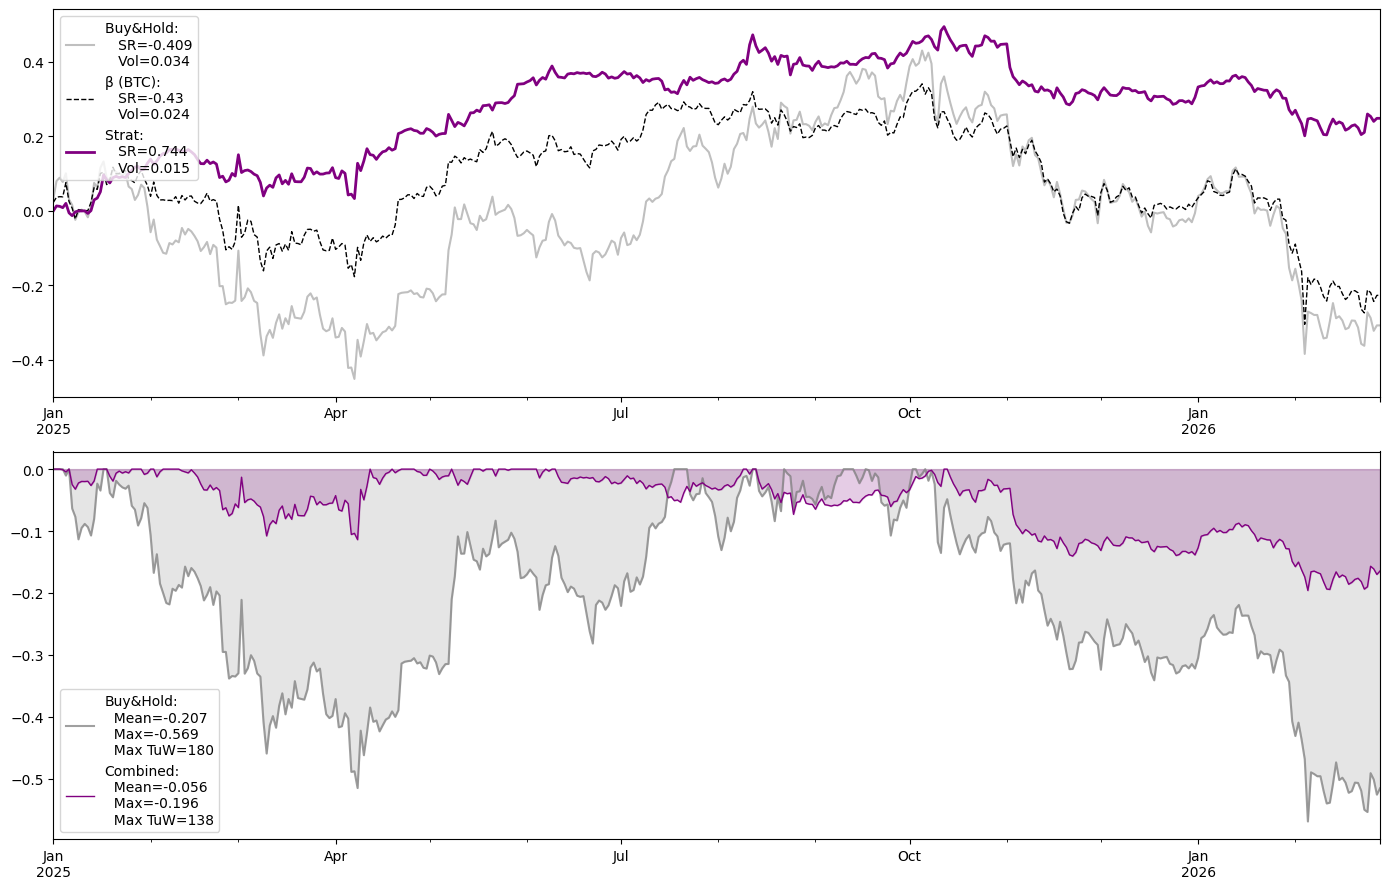

Turnover: 0.108


<Figure size 640x480 with 0 Axes>

In [17]:
regime_strat = RegimePredictionStrat(
    universe=SHORT_UNIV,
    hist_start_date_str=hist_start_date_str,
    hist_end_date_str=hist_end_date_str,
    fut_start_date_str=fut_start_date_str,
    fut_end_date_str=fut_end_date_str,
    fee=fee
)

regime_outputs = regime_strat.run_historical(
    rolling_window=366,
    random_state=12345
)
regime_strat_rets, regime_strat_wgts, regime_strat_sr, regime_strat_vol, regime_oos_strat_rets, regime_oos_strat_wgts = regime_outputs

In [18]:
regime_strat_sr = sharpe_ratio(regime_oos_strat_rets.sum(1), n_periods=365)
regime_strat_vol = regime_oos_strat_rets.sum(1).std()

regime_strat_alpha_coeff = 0.0008
regime_strat_t_stat = 1.542

strat_name = 'oos_ml_regimes_strat'    
validation_stats = pd.concat([
    validation_stats, 
    pd.DataFrame(
        {
            'total_returns': regime_oos_strat_rets.sum(1).sum(),
            'sharpe_ratio': regime_strat_sr,
            'bnh_sharpe_ratio': bnh_sr,
            'volatility': regime_strat_vol,
            'α_coeff': regime_strat_alpha_coeff,
            'α_t_stat': regime_strat_t_stat,
            'IR': information_ratio(regime_oos_strat_rets.sum(1), oos_bnh_rets, 365)
        }, index=[strat_name]
    )
])
validation_stats

,total_returns,sharpe_ratio,bnh_sharpe_ratio,volatility,α_coeff,α_t_stat,IR
tech_strat,0.637560,1.890177,1.112811,0.017607,0.0016,1.171,-0.138999
ml_returns_strat,0.241234,1.553406,1.112811,0.008106,0.0003,0.737,-0.710259
ml_regimes_strat,0.263314,0.668514,1.112811,0.020560,0.0002,0.187,-0.571849
comb_eq_dol_strat,0.382187,2.078953,1.112811,0.009596,0.0010,1.926,-0.521228
oos_tech_strat,0.645185,1.851290,-0.576611,0.015703,-0.0006,-0.491,1.267935
oos_ml_returns_strat,0.164907,0.892694,-0.576611,0.008324,0.0005,1.489,0.754360
oos_ml_regimes_strat,0.248206,0.744020,-0.576611,0.015032,0.0008,1.542,0.800274


## Combine OOS strats

In [19]:
dol_wgts = get_equal_dollar_weights(3)
eq_dol_combined_strat_rets = (dol_wgts[0]*tech_strat_oos_rets).add(dol_wgts[1]*ret_pred_oos_strat_rets + dol_wgts[2]*regime_oos_strat_rets, fill_value=0)

hist_sr_arr = np.array(validation_rets.drop(['comb_eq_dol_strat'], axis=1).apply(lambda x: sharpe_ratio(x, n_periods=365)))
sr_wgts = get_sharpe_ratio_weights(hist_sr_arr)
eq_sr_combined_strat_rets = (sr_wgts[0]*tech_strat_oos_rets).add(sr_wgts[1]*ret_pred_oos_strat_rets + sr_wgts[2]*regime_oos_strat_rets, fill_value=0)

vol_wgts = get_equal_volatility_weights(np.array([tech_strat_vol, ret_pred_strat_vol, regime_strat_vol]))
eq_vol_combined_strat_rets = (vol_wgts[0]*tech_strat_oos_rets).add(vol_wgts[1]*ret_pred_oos_strat_rets + vol_wgts[2]*regime_oos_strat_rets, fill_value=0)

gen_wgts = get_general_weights(validation_rets.drop(['comb_eq_dol_strat'], axis=1))
gen_combined_strat_rets = (gen_wgts[0]*tech_strat_oos_rets).add(gen_wgts[1]*ret_pred_oos_strat_rets + gen_wgts[2]*regime_oos_strat_rets, fill_value=0)

In [20]:
comb_eq_dol_strat_sr = sharpe_ratio(eq_dol_combined_strat_rets.sum(1), 365)
comb_eq_dol_strat_vol = eq_dol_combined_strat_rets.sum(1).std()

comb_eq_sr_strat_sr = sharpe_ratio(eq_sr_combined_strat_rets.sum(1),  365)
comb_eq_sr_strat_vol = eq_sr_combined_strat_rets.sum(1).std()

comb_eq_vol_strat_sr = sharpe_ratio(eq_vol_combined_strat_rets.sum(1), 365)
comb_eq_vol_strat_vol = eq_vol_combined_strat_rets.sum(1).std()

comb_gen_strat_sr = sharpe_ratio(gen_combined_strat_rets.sum(1), 365)
comb_gen_strat_vol = gen_combined_strat_rets.sum(1).std()

In [21]:
print(f"Equal dol volatility: {np.round(comb_eq_dol_strat_vol, 3)}")
print(f"Equal sr volatility: {np.round(comb_eq_sr_strat_vol, 3)}")
print(f"Equal vol volatility: {np.round(comb_eq_vol_strat_vol, 3)}")
print(f"General wgt volatility: {np.round(comb_gen_strat_vol, 3)}")

Equal dol volatility: 0.009
Equal sr volatility: 0.009
Equal vol volatility: 0.008
General wgt volatility: 0.008


In [22]:
print(f"Equal dol tot rets: {np.round(eq_dol_combined_strat_rets.sum(1).sum(), 4)}")
print(f"Equal sr tot rets: {np.round(eq_sr_combined_strat_rets.sum(1).sum(), 3)}")
print(f"Equal vol tot rets: {np.round(eq_vol_combined_strat_rets.sum(1).sum(), 3)}")
print(f"General wgt tot rets: {np.round(gen_combined_strat_rets.sum(1).sum(), 3)}")

Equal dol tot rets: 0.3498
Equal sr tot rets: 0.396
Equal vol tot rets: 0.305
General wgt tot rets: 0.34


In [23]:
beta, results = calc_beta(np.array(oos_beta_rets), np.array(eq_dol_combined_strat_rets.sum(1)))
print("EQUAL DOLLAR")
print(f"IR: {information_ratio(eq_dol_combined_strat_rets.sum(1), oos_bnh_rets, 365)}")
print(results.summary())
print()

beta, results = calc_beta(np.array(oos_beta_rets), np.array(eq_vol_combined_strat_rets.sum(1)))
print("EQUAL VOLATILITY")
print(f"IR: {information_ratio(eq_vol_combined_strat_rets.sum(1), oos_bnh_rets, 365)}")
print(results.summary())
print()

beta, results = calc_beta(np.array(oos_beta_rets), np.array(eq_sr_combined_strat_rets.sum(1)))
print("EQUAL SHARPE RATIO")
print(f"IR: {information_ratio(eq_sr_combined_strat_rets.sum(1), oos_bnh_rets, 365)}")
print(results.summary())
print()

beta, results = calc_beta(np.array(oos_beta_rets), np.array(gen_combined_strat_rets.sum(1)))
print("GENERAL WEIGHTS")
print(f"IR: {information_ratio(gen_combined_strat_rets.sum(1), oos_bnh_rets, 365)}")
print(results.summary())
print()

EQUAL DOLLAR
IR: 0.9691973849801553
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3548
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.552
Time:                        20:47:59   Log-Likelihood:                 1401.3
No. Observations:                 424   AIC:                            -2799.
Df Residuals:                     422   BIC:                            -2790.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.02035
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.887
Time:                        20:47:59   Log-Likelihood:                 1395.4
No. Observations:                 424   AIC:                            -2787.
Df Residuals:                     422   BIC:                            -2779.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      2.126      0.0

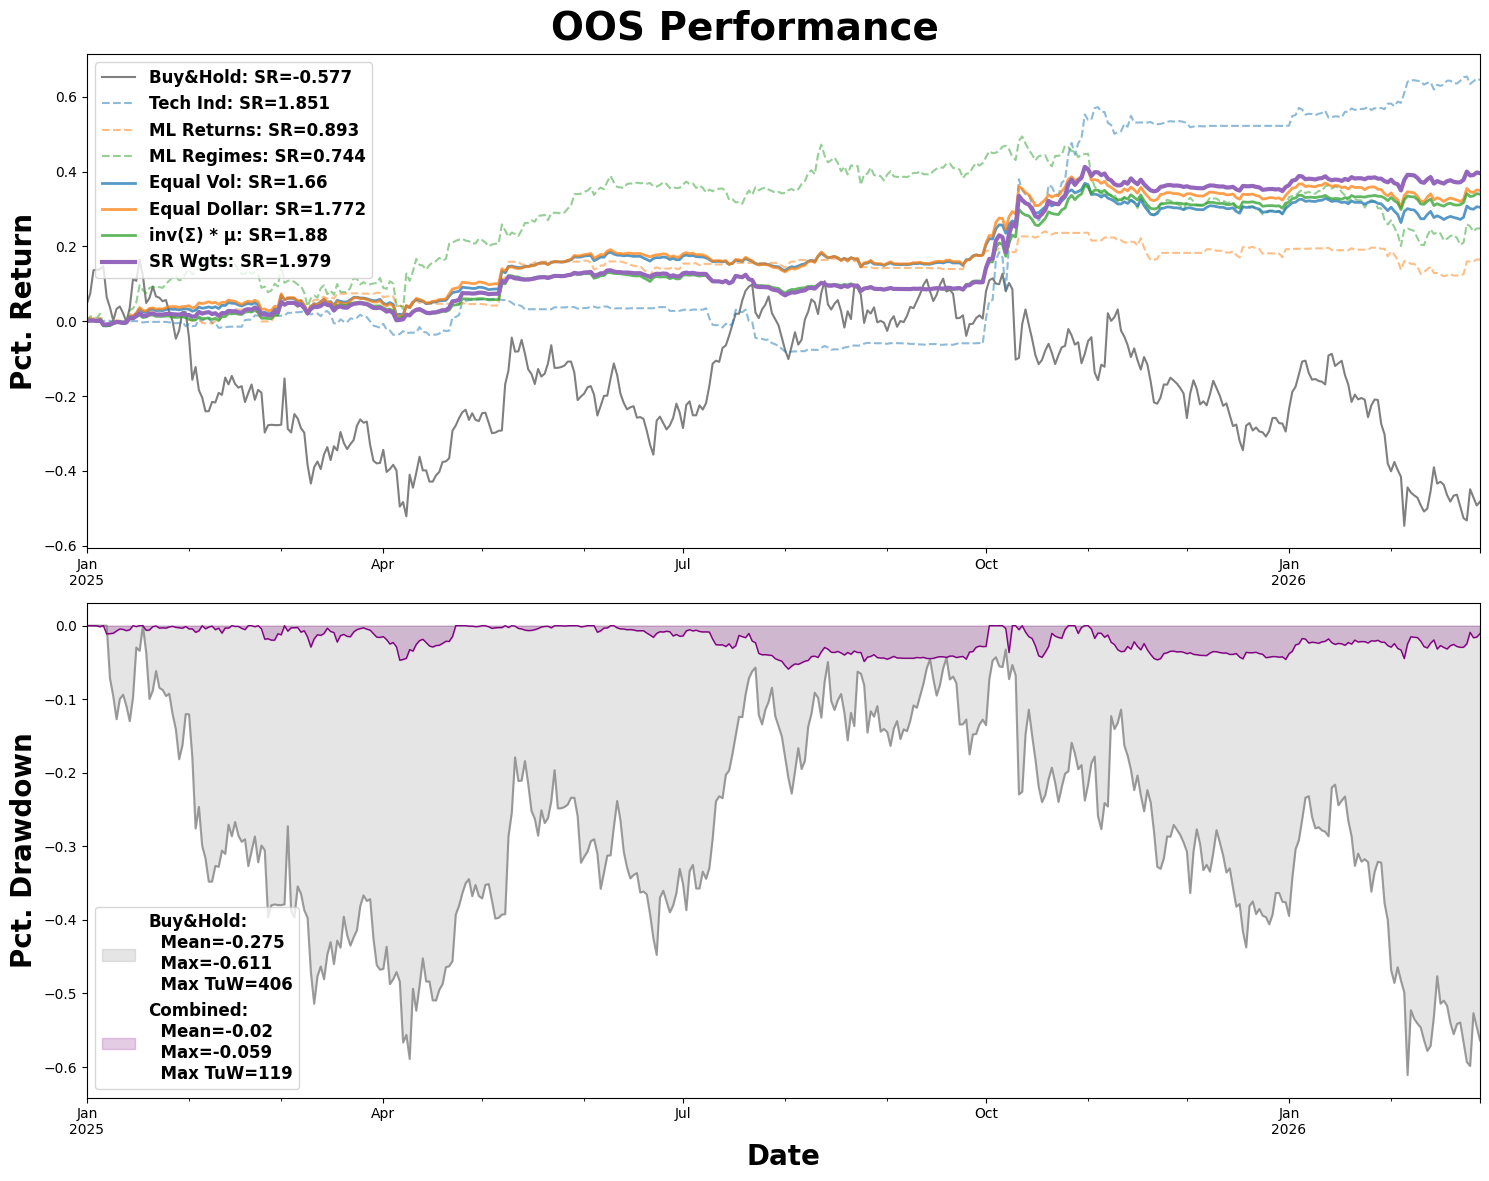

<Figure size 640x480 with 0 Axes>

In [24]:
# drawdowns
bnh_drawdown = get_drawdown_array(oos_bnh_rets)
strat_drawdown = get_drawdown_array(eq_sr_combined_strat_rets.sum(1))

beta, results = calc_beta(np.array(oos_beta_rets), np.array(eq_sr_combined_strat_rets.sum(1)))
print(results.summary())

fig, axs = plt.subplots(2, 1, figsize=(15, 12))

oos_bnh_rets.cumsum().plot(ax=axs[0], color='black', alpha=0.5, label=f"Buy&Hold: SR={np.round(sharpe_ratio(oos_bnh_rets, 365), 3)}")
tech_strat_oos_rets.sum(1).cumsum().plot(ax=axs[0], linestyle='--', alpha=0.5, label=f"Tech Ind: SR={np.round(sharpe_ratio(tech_strat_oos_rets.sum(1), 365), 3)}")
ret_pred_oos_strat_rets.sum(1).cumsum().plot(ax=axs[0], linestyle='--', alpha=0.5, label=f"ML Returns: SR={np.round(sharpe_ratio(ret_pred_oos_strat_rets.sum(1), 365), 3)}")
regime_oos_strat_rets.sum(1).cumsum().plot(ax=axs[0], linestyle='--', alpha=0.5, label=f"ML Regimes: SR={np.round(sharpe_ratio(regime_oos_strat_rets.sum(1), 365), 3)}")
eq_vol_combined_strat_rets.sum(1).cumsum().plot(ax=axs[0], color='tab:blue', alpha=0.75, linewidth=2, label=f"Equal Vol: SR={np.round(sharpe_ratio(eq_vol_combined_strat_rets.sum(1), 365), 3)}")
eq_dol_combined_strat_rets.sum(1).cumsum().plot(ax=axs[0], color='tab:orange', alpha=0.75, linewidth=2, label=f"Equal Dollar: SR={np.round(sharpe_ratio(eq_dol_combined_strat_rets.sum(1), 365), 3)}")
gen_combined_strat_rets.sum(1).cumsum().plot(ax=axs[0], color='tab:green', alpha=0.75, linewidth=2, label=f"inv(Σ) * μ: SR={np.round(sharpe_ratio(gen_combined_strat_rets.sum(1), 365), 3)}")
eq_sr_combined_strat_rets.sum(1).cumsum().plot(ax=axs[0], color='tab:purple', linewidth=3, label=f"SR Wgts: SR={np.round(sharpe_ratio(eq_sr_combined_strat_rets.sum(1), 365), 3)}")

bnh_drawdown.plot(ax=axs[1], color='gray', alpha=0.75)
axs[1].fill_between(bnh_drawdown.index, bnh_drawdown, y2=0, color='gray', alpha=0.2, label=f"Buy&Hold:\n  Mean={np.round(bnh_drawdown.mean(), 3)}\n  Max={np.round(bnh_drawdown.min(), 3)}\n  Max TuW={max_time_under_water(bnh_drawdown)}")
strat_drawdown.plot(ax=axs[1], color='purple', linewidth=1)
axs[1].fill_between(strat_drawdown.index, strat_drawdown, y2=0, color='purple', alpha=0.2, label=f"Combined:\n  Mean={np.round(strat_drawdown.mean(), 3)}\n  Max={np.round(strat_drawdown.min(), 3)}\n  Max TuW={max_time_under_water(strat_drawdown)}")

axs[0].set_ylabel('Pct. Return', size=20,  weight='bold')
axs[0].legend(loc='upper left', prop={'size': 12, 'weight': 'bold'})
axs[1].set_xlabel('Date', size=20, weight='bold')
axs[1].set_ylabel('Pct. Drawdown', size=20,  weight='bold')
axs[1].legend(loc='lower left', prop={'size': 12, 'weight': 'bold'})
plt.suptitle('OOS Performance', size=28, weight='bold')
plt.tight_layout()
#plt.savefig('quant_strats_oos_perf.png')
plt.show()
plt.clf()

#os.system('open quant_strats_oos_perf.png')

In [25]:
validation_stats

,total_returns,sharpe_ratio,bnh_sharpe_ratio,volatility,α_coeff,α_t_stat,IR
tech_strat,0.637560,1.890177,1.112811,0.017607,0.0016,1.171,-0.138999
ml_returns_strat,0.241234,1.553406,1.112811,0.008106,0.0003,0.737,-0.710259
ml_regimes_strat,0.263314,0.668514,1.112811,0.020560,0.0002,0.187,-0.571849
comb_eq_dol_strat,0.382187,2.078953,1.112811,0.009596,0.0010,1.926,-0.521228
oos_tech_strat,0.645185,1.851290,-0.576611,0.015703,-0.0006,-0.491,1.267935
oos_ml_returns_strat,0.164907,0.892694,-0.576611,0.008324,0.0005,1.489,0.754360
oos_ml_regimes_strat,0.248206,0.744020,-0.576611,0.015032,0.0008,1.542,0.800274


### Non-normalized turnover

In [26]:
# need to normalize these here, they are normalized within the strat class, 
# but the weights returned from running historical are the non-normalized version
normed_ret_pred_oos_strat_wgts = ret_pred_oos_strat_wgts / ret_pred_oos_strat_wgts.shape[1]

# equal dollar weights
eq_dol_wgts = (dol_wgts[0]*tech_strat_oos_wgts).add(dol_wgts[1]*normed_ret_pred_oos_strat_wgts + dol_wgts[2]*regime_oos_strat_wgts, fill_value=0)
eq_dol_turnover = calculate_turnover(eq_dol_wgts)

# equal volatility weights
eq_vol_wgts = vol_wgts[0]*tech_strat_oos_wgts.add(vol_wgts[1]*normed_ret_pred_oos_strat_wgts + vol_wgts[2]*regime_oos_strat_wgts, fill_value=0)
eq_vol_turnover = calculate_turnover(eq_vol_wgts)

# sharpe_ratio weights
eq_sr_wgts = (sr_wgts[0]*tech_strat_oos_wgts).add(sr_wgts[1]*normed_ret_pred_oos_strat_wgts + sr_wgts[2]*regime_oos_strat_wgts, fill_value=0)
sr_wgt_turnover = calculate_turnover(eq_sr_wgts)

# general weights
gen_strat_wgts = gen_wgts[0]*tech_strat_oos_wgts.add(gen_wgts[1]*normed_ret_pred_oos_strat_wgts + gen_wgts[2]*regime_oos_strat_wgts, fill_value=0)
gen_wgt_turnover = calculate_turnover(gen_strat_wgts)

print("Turnover")
print("--------")
print(f"Eq dol: {eq_dol_turnover}")
print(f"Eq vol: {eq_vol_turnover}")
print(f"SR wgt: {sr_wgt_turnover}")
print(f"Genwgt: {gen_wgt_turnover}")

Turnover
--------
Eq dol: 0.06651915554665302
Eq vol: 0.030130575095363824
SR wgt: 0.0698957621511884
Genwgt: 0.04173777903358379


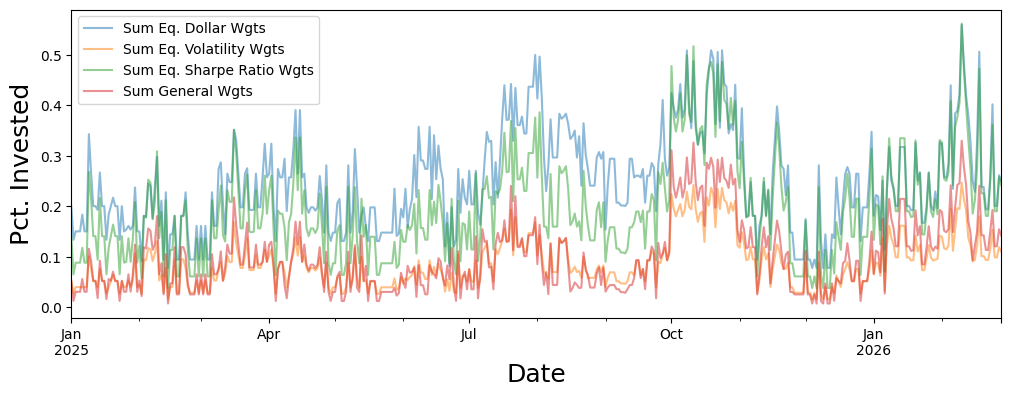

<Figure size 640x480 with 0 Axes>

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

eq_dol_wgts.abs().sum(1).plot(ax=ax, alpha=0.5, label="Sum Eq. Dollar Wgts")
eq_vol_wgts.abs().sum(1).plot(ax=ax, alpha=0.5, label="Sum Eq. Volatility Wgts")
eq_sr_wgts.abs().sum(1).plot(ax=ax, alpha=0.5, label="Sum Eq. Sharpe Ratio Wgts")
gen_strat_wgts.abs().sum(1).plot(ax=ax, alpha=0.5, label="Sum General Wgts")
plt.xlabel('Date', size=18)
plt.ylabel('Pct. Invested', size=18)
plt.legend(loc='upper left')
plt.show()
plt.clf()